# Project 3: Global Mental Health Crisis Index 2026

**Objective**: Showcase 5 of the 7 potential use cases from this dataset using EDA, statistical tests, and regression modeling.

**Type**: Exploratory Data Analysis (EDA) + Confirmatory Data Analysis (CDA)

**Dataset**: `Global_Mental_Health_Crisis_Index_2026.csv` — 92 countries, 29 variables covering mental health prevalence, systems, policy, digital behavior, and COVID-19 impact.

## Use Cases Covered
1. **Visualization & Dashboards** — Regional overview of key indicators
2. **Social Media & Mental Health** — Screen time vs anxiety/depression rates
3. **COVID-19 Aftermath** — Which regions saw the largest pandemic-era surge
4. **Inequality Research** — High-income vs low-income country disparities
5. **Regression & Prediction** — Modeling the crisis index from economic and policy variables

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
p

## 1. Load & Validate

In [3]:
df = pd.read_csv('Global_Mental_Health_Crisis_Index_2026.csv')
print('Dataset Loaded:', df.shape)
df.head()

Dataset Loaded: (92, 29)


,country,iso3,region,income_group,depression_pct,anxiety_pct,suicide_rate_per100k,psychiatrists_per100k,mh_budget_pct_health,mh_spend_usd_per_capita,treatment_gap_pct,social_media_hours_daily,internet_penetration_pct,gdp_per_capita_usd,population_millions,covid_mh_increase_pct,youth_mh_crisis_score,mh_policy_exists,mh_law_exists,mh_crisis_index,total_affected_millions,psychiatrists_per_million,mh_investment_gap,social_media_mental_health_risk,depression_anxiety_comorbidity_est_pct,mh_system_score,income_group_code,data_year,data_source
0,Malawi,MWI,Africa,Low,3.3,4.5,6.5,0.02,0.8,0.1,97,1.1,16,700,20.4,86,9.5,No,No,87,1.59,0.2,0.078,Low (<1.5h),1.65,3.4,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
1,Mozambique,MOZ,Africa,Low,3.4,4.6,8.2,0.04,0.6,0.1,96,1.2,18,600,32.8,85,9.4,No,No,86,2.62,0.4,0.058,Low (<1.5h),1.70,3.1,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
2,Ethiopia,ETH,Africa,Low,3.5,4.8,10.2,0.04,1.0,0.1,95,1.4,22,1200,123.4,82,9.3,No,No,84,10.24,0.4,0.095,Low (<1.5h),1.75,4.7,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
3,Zimbabwe,ZWE,Africa,Low,4.0,5.2,15.4,0.05,0.7,0.1,94,2.1,35,1000,15.9,82,9.3,No,No,83,1.46,0.5,0.066,Moderate (1.5-2.5h),2.00,4.1,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
4,Tanzania,TZA,Africa,Low,3.6,4.9,8.6,0.04,0.8,0.1,94,1.6,28,1200,65.5,80,9.2,No,No,82,5.57,0.4,0.075,Moderate (1.5-2.5h),1.80,4.4,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...


In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df.describe().round(2)

## Feature Engineering

We create three composite features before analysis:
- `mh_burden_score` — combines depression, anxiety, and suicide rate into one burden score
- `resource_ratio` — psychiatrists available relative to crisis severity
- `digital_risk` — social media exposure adjusted for internet penetration

In [15]:
df['mh_burden_score'] = df['depression_pct'] + df['anxiety_pct'] + df['suicide_rate_per100k'] / 10
df['resource_ratio']  = df['psychiatrists_per_million'] / (df['mh_crisis_index'] + 1)
df['digital_risk']    = df['social_media_hours_daily'] * df['internet_penetration_pct'] / 100

df[['mh_burden_score', 'resource_ratio', 'digital_risk']].describe().round(2)

,mh_burden_score,resource_ratio,digital_risk
count,92.00,92.00,92.00
mean,11.19,1.59,1.64
std,2.03,2.35,0.72
min,7.22,0.00,0.01
25%,9.62,0.08,1.28
50%,10.86,0.43,1.71
75%,12.27,2.62,2.09
max,19.35,14.45,3.19


## Use Case 1: Visualization & Regional Overview

How do depression, anxiety, and crisis index vary across regions? We start with distributions then compare by region.

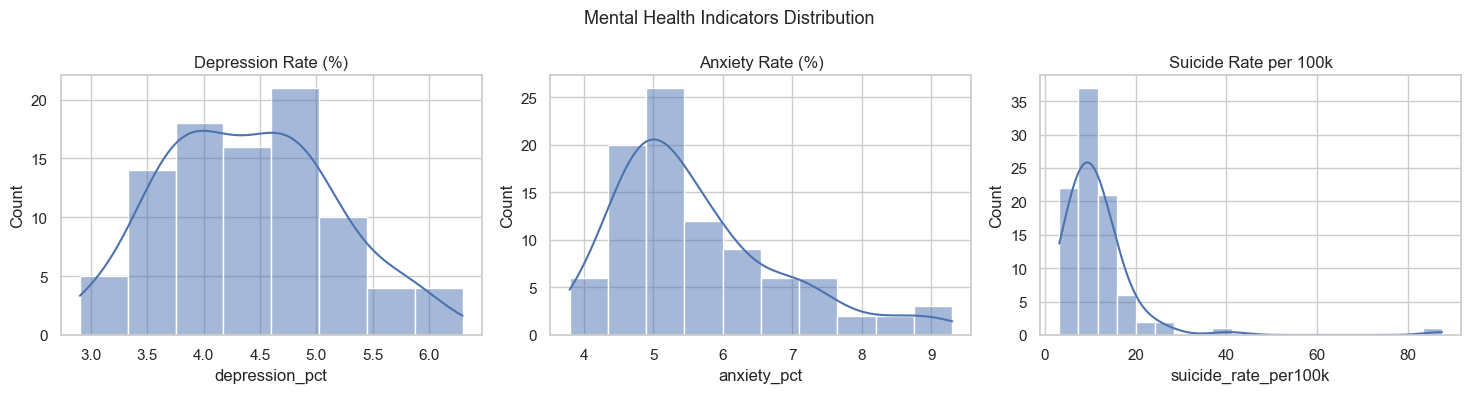

In [4]:
# Distribution of the 3 main mental health indicators
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['depression_pct'], kde=True, ax=axes[0])
axes[0].set_title('Depression Rate (%)')

sns.histplot(df['anxiety_pct'], kde=True, ax=axes[1])
axes[1].set_title('Anxiety Rate (%)')

sns.histplot(df['suicide_rate_per100k'], kde=True, ax=axes[2])
axes[2].set_title('Suicide Rate per 100k')

plt.suptitle('Mental Health Indicators Distribution', fontsize=13)
plt.tight_layout()
plt.show()

### Regional comparison (small multiples)

In [5]:
# Average of 4 indicators by region
region_avg = df.groupby('region')[['depression_pct', 'anxiety_pct', 'mh_crisis_index', 'treatment_gap_pct']].mean().round(2)
region_avg.sort_values('mh_crisis_index', ascending=False)

,depression_pct,anxiety_pct,mh_crisis_index,treatment_gap_pct
region,,,,
Africa,3.95,5.40,78.21,91.50
S-E Asia,3.85,5.12,65.55,81.82
E. Med,4.26,7.23,61.00,67.78
Americas,4.81,6.53,59.08,61.38
W. Pacific,3.90,4.83,52.62,49.15
Europe,4.87,5.42,48.31,37.31


C:\Users\MA\AppData\Local\Temp\ipykernel_20996\3462413772.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order, y=region_avg[metric][order].values, palette='tab10', ax=ax)
C:\Users\MA\AppData\Local\Temp\ipykernel_20996\3462413772.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order, y=region_avg[metric][order].values, palette='tab10', ax=ax)
C:\Users\MA\AppData\Local\Temp\ipykernel_20996\3462413772.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order, y=region_avg[metric][order].values, palette='tab10', ax=ax)
C:\Users\M

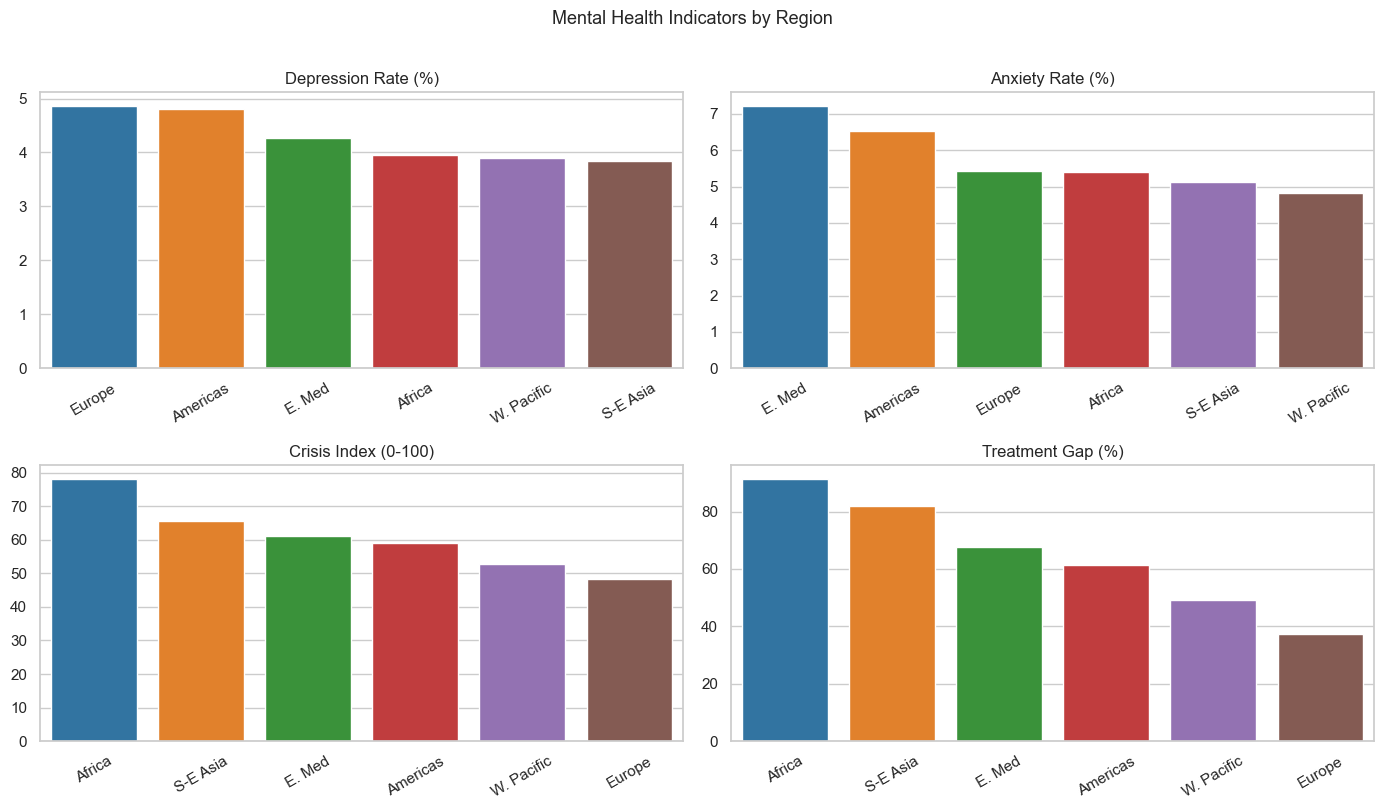

In [ ]:
metrics = ['depression_pct', 'anxiety_pct', 'mh_crisis_index', 'treatment_gap_pct']
labels  = ['Depression Rate (%)', 'Anxiety Rate (%)', 'Crisis Index (0-100)', 'Treatment Gap (%)']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, metric, label in zip(axes, metrics, labels):
    order = region_avg[metric].sort_values(ascending=False).index
    sns.barplot(x=order, y=region_avg[metric][order].values, palette='tab10', ax=ax)
    ax.set_title(label)
    ax.set_xlabel('')

plt.suptitle('Mental Health Indicators by Region', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Use Case 2: Social Media & Mental Health

Does higher daily social media usage correlate with elevated anxiety or depression rates?

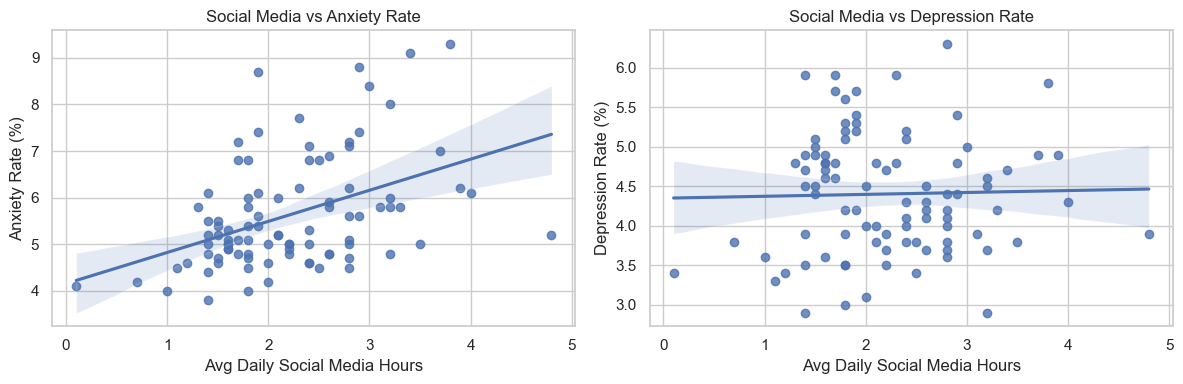

In [7]:
# Social media vs anxiety and depression
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.regplot(data=df, x='social_media_hours_daily', y='anxiety_pct', ax=axes[0])
axes[0].set_title('Social Media vs Anxiety Rate')
axes[0].set_xlabel('Avg Daily Social Media Hours')
axes[0].set_ylabel('Anxiety Rate (%)')

sns.regplot(data=df, x='social_media_hours_daily', y='depression_pct', ax=axes[1])
axes[1].set_title('Social Media vs Depression Rate')
axes[1].set_xlabel('Avg Daily Social Media Hours')
axes[1].set_ylabel('Depression Rate (%)')

plt.tight_layout()
plt.show()

In [25]:
# Statistical confirmation
alpha = 0.05

for target, label in [('anxiety_pct', 'Anxiety'), ('depression_pct', 'Depression')]:
    r, p = pearsonr(df['social_media_hours_daily'], df[target])
    print(f'Social Media vs {label}: r={r}, p={p}')
    if p <= alpha:
        print(f'  Conclusion: Significant association with {label}')
    else:
        print(f'  Conclusion: No significant association with {label}')

Social Media vs Anxiety: r=0.43661224980558466, p=1.3550696916066691e-05
  Conclusion: Significant association with Anxiety
Social Media vs Depression: r=0.025142860399407968, p=0.8119570128269674
  Conclusion: No significant association with Depression


## Use Case 3: COVID-19 Aftermath

Which regions and income groups experienced the largest pandemic-era mental health surge?

In [9]:
df.groupby('region')['covid_mh_increase_pct'].mean().round(2).sort_values(ascending=False)

region
Africa        74.07
S-E Asia      58.00
E. Med        54.44
Americas      49.38
W. Pacific    45.08
Europe        36.66
Name: covid_mh_increase_pct, dtype: float64

C:\Users\MA\AppData\Local\Temp\ipykernel_20996\2202662575.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='region', y='covid_mh_increase_pct', order=order, palette='tab10', ax=axes[0])
C:\Users\MA\AppData\Local\Temp\ipykernel_20996\2202662575.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='income_group', y='covid_mh_increase_pct', order=income_order, palette='Set2', ax=axes[1])


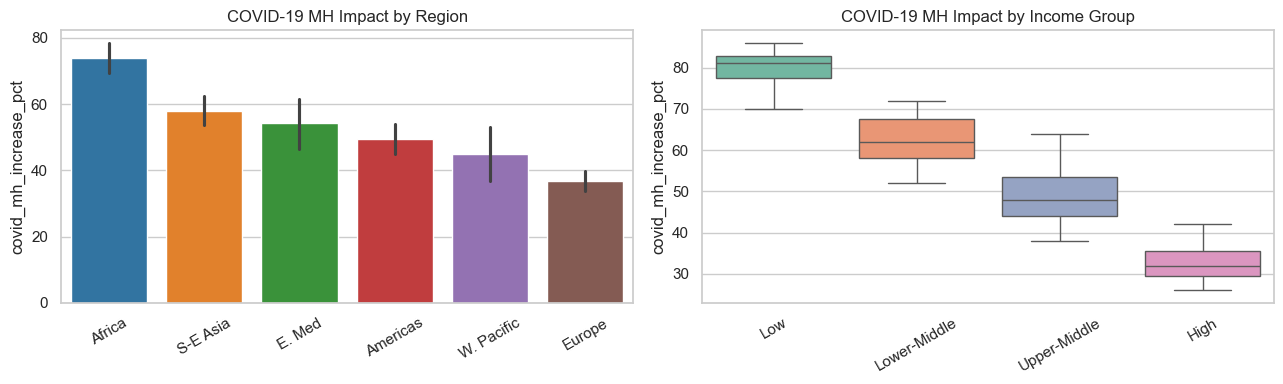

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

order = df.groupby('region')['covid_mh_increase_pct'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='region', y='covid_mh_increase_pct', order=order, palette='tab10', ax=axes[0])
axes[0].set_title('COVID-19 MH Impact by Region')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

income_order = df.groupby('income_group')['covid_mh_increase_pct'].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x='income_group', y='covid_mh_increase_pct', order=income_order, palette='Set2', ax=axes[1])
axes[1].set_title('COVID-19 MH Impact by Income Group')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

In [26]:
# Are regional differences statistically significant?
alpha = 0.05

groups = [g['covid_mh_increase_pct'].values for _, g in df.groupby('region')]
f_stat, p = f_oneway(*groups)

print(f'ANOVA (COVID impact ~ Region): F={f_stat}, p={p}')
if p <= alpha:
    print('Conclusion: Significant regional differences in COVID-19 MH impact')
else:
    print('Conclusion: No significant regional difference')

ANOVA (COVID impact ~ Region): F=27.919221292111747, p=1.075947177296503e-16
Conclusion: Significant regional differences in COVID-19 MH impact


## Use Case 4: Inequality Research

How do high-income vs low-income countries compare on mental health access and crisis severity?

In [12]:
df.groupby('income_group')[['treatment_gap_pct', 'psychiatrists_per100k', 'mh_spend_usd_per_capita', 'mh_system_score']].mean().round(2)

,treatment_gap_pct,psychiatrists_per100k,mh_spend_usd_per_capita,mh_system_score
income_group,,,,
High,27.14,16.02,96.57,63.07
Low,94.25,0.10,0.11,4.49
Lower-Middle,84.04,0.62,0.93,10.10
Upper-Middle,66.65,3.62,7.76,22.89


<Axes: xlabel='gdp_per_capita_usd', ylabel='mh_crisis_index'>

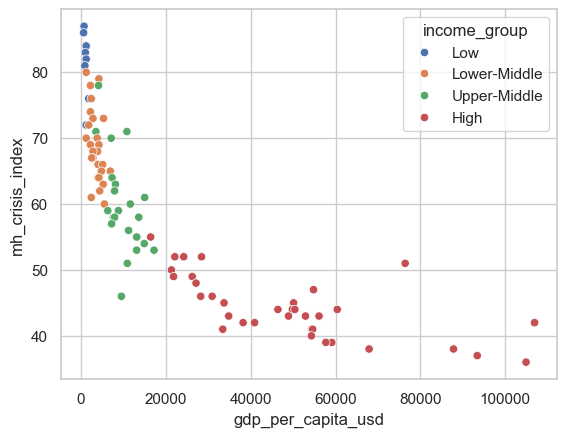

In [23]:
# GDP vs Crisis Index — wealth vs mental health burden

sns.scatterplot(data=df, x='gdp_per_capita_usd', y='mh_crisis_index', hue='income_group')


In [27]:
alpha = 0.05

chi2, p, _, _ = chi2_contingency(pd.crosstab(df['mh_policy_exists'], df['income_group']))
print(f'Chi-square (Policy vs Income Group): chi2={chi2}, p={p}')
if p <= alpha:
    print('Conclusion: Income group is significantly associated with having an MH policy')
else:
    print('Conclusion: No significant association')

Chi-square (Policy vs Income Group): chi2=45.0957264957265, p=8.829254477873014e-10
Conclusion: Income group is significantly associated with having an MH policy


## Use Case 5: Regression & Prediction



In [19]:
model = smf.ols(
    'mh_crisis_index ~ mh_burden_score + digital_risk + psychiatrists_per_million + treatment_gap_pct',
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        mh_crisis_index   R-squared:                       0.922
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                     258.6
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           2.08e-47
Time:                        00:23:10   Log-Likelihood:                -252.82
No. Observations:                  92   AIC:                             515.6
Df Residuals:                      87   BIC:                             528.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

### PCA — Country clustering by mental health profile

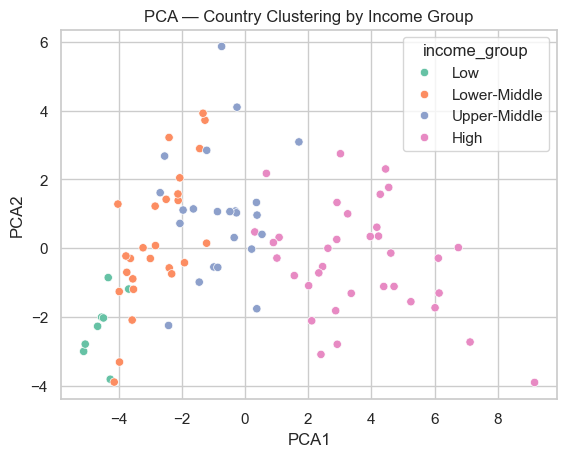

In [20]:
features = df.select_dtypes(include=np.number).drop(columns=['income_group_code', 'data_year'])
scaled   = StandardScaler().fit_transform(features)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='income_group', palette='Set2')
plt.title('PCA — Country Clustering by Income Group')
plt.show()

## Summary

**Use Case 1 — Regional Overview**
Africa has the highest crisis index (78.21) and treatment gap (91.50%), while Europe has the lowest. Depression and anxiety distributions are right-skewed — a few countries carry extreme burden.

**Use Case 2 — Social Media & Mental Health**
Social media hours are significantly correlated with anxiety (r=0.437, p<0.001) but not depression (r=0.025, p=0.81). Higher screen time is a meaningful anxiety risk signal at the country level.

**Use Case 3 — COVID-19 Aftermath**
Africa saw the largest surge (+74.07%), followed by S-E Asia (+58%). Low-income countries averaged +79.38% vs +33.11% for High-income. Regional differences are statistically significant (ANOVA p<0.001).

**Use Case 4 — Inequality Research**
High-income countries have 16.02 psychiatrists per 100k vs 0.10 in Low-income countries. MH spending is $96.57 vs $0.11 per capita. Income group is significantly associated with having a formal MH policy (chi-square p<0.001).

**Use Case 5 — Regression & Prediction**
The OLS model explains 92.2% of variance in the crisis index (R²=0.922). `treatment_gap_pct` (coef=0.484) and `mh_burden_score` (coef=1.397) are the strongest significant predictors. `digital_risk` has a negative coefficient (-3.18), suggesting digitally connected countries tend to have better systems. `psychiatrists_per_million` was not significant (p=0.547).

**Future work**: Add country-fixed effects; test non-linear models; incorporate time-series data to track trends.